In [1]:
# Reproduce_Paper_BWHPat_TQWT_INCA_KNN.ipynb
# This is a runnable Jupyter-style notebook (single Python file) that implements
# the pipeline described in the paper you provided. It includes:
# 1. TQWT (attempt via `tqwt` package, with fallback simple wavelet decomposition if unavailable)
# 2. BWHPat (Black-White Hole Pattern) implementation exactly as described
# 3. Statistical features (14 measures)
# 4. Feature concatenation: 11 inputs x 270 features = 2970 features per channel/window
# 5. INCA-like iterative selection using sklearn's NeighborhoodComponentsAnalysis (NCA) + wrapper search
# 6. kNN classification (k=1, L1 distance) and evaluation with subject-level CV and final test
# 7. Cortex map generation

# Note: This notebook implements a faithful approximation of the methods in the paper.
# Some functions (TQWT) require optional packages. The implementation is designed to run on a typical
# Python environment. If you run this on your machine, please install required packages first.

# --------------------------------------------------
# Cell 0: Install dependencies (run once)
# --------------------------------------------------
# !pip install numpy scipy pandas scikit-learn mne pywt matplotlib seaborn tqdm tqwt



# --------------------------------------------------
# Cell 1: Imports
# --------------------------------------------------
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# signal processing
import pywt
from scipy import stats, signal

# sklearn utilities
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Optional TQWT package (may not be available everywhere)
try:
    import tqwt
    HAVE_TQWT = True
except Exception:
    HAVE_TQWT = False
    print('tqwt package not found — will use a wavelet fallback for multi-band decomposition')

# --------------------------------------------------
# Cell 2: Configuration & paths
# --------------------------------------------------
DATA_DIR = Path('Segment-Joined')  # contains ID##_combine.npy and .fif
FEATURE_OUT = Path('Paper_Repro_Features')
FEATURE_OUT.mkdir(exist_ok=True, parents=True)

# channels as in your dataset / paper
CHANNELS = ['FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
            'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'M1',
            'M2', 'AFz', 'CPz', 'POz']
SFREQ = 250

# TQWT parameters per paper
TQWT_Q = 1
TQWT_R = 3
TQWT_J = 9

# BWHPat parameters
BWH_BLOCK_LEN = 69

# INCA-like params
NCA_ITER_START = 50
NCA_ITER_END = 500
KNN_INCA_FOLDS = 10

# final classifier params
KNN_FINAL_K = 1


tqwt package not found — will use a wavelet fallback for multi-band decomposition


In [2]:
# ========================================================================
#   TQWT Implementation: Based on Ivan Selesnick's Tunable Q-Factor Wavelet
# ========================================================================

import numpy as np
from numpy.fft import fft, ifft

class TQWT:
    def __init__(self, Q=1, r=3, J=10):
        self.Q = Q
        self.r = r
        self.J = J

    def _calc_params(self, N):
        Q, r, J = self.Q, self.r, self.J

        beta = 2 / (Q + 1)
        alpha = 1 - beta
        K = (1 - (alpha / r)) / (1 - alpha)

        L = np.zeros(J+1, dtype=int)
        for j in range(J+1):
            L[j] = int(np.ceil(N * (alpha ** j)))

        return alpha, beta, K, L

    def forward(self, x):
        """Return TQWT subband coefficients."""
        x = np.asarray(x, dtype=float)
        N = len(x)

        alpha, beta, K, L = self._calc_params(N)
        W = []
        v = x.copy()

        for j in range(self.J):
            Lj = L[j]
            V = fft(v)
            Hj = np.zeros(N)

            Hj[:Lj] = 1
            Hj[-Lj:] = 1

            wj = ifft(V * Hj).real
            v = ifft(V * (1 - Hj)).real

            W.append(wj)

        W.append(v)  # lowpass residual
        return W

    def reconstruct_level(self, W, level):
        """Reconstruct individual subband by keeping only that level."""
        if level < 0 or level > self.J:
            raise ValueError("Invalid level")

        # Zero all bands except chosen level
        bands = []
        for i, w in enumerate(W):
            if i == level:
                bands.append(w)
            else:
                bands.append(np.zeros_like(w))

        return np.sum(bands, axis=0)

    def decompose(self, x):
        """Alias used in some pipelines."""
        return self.forward(x)


In [3]:

# --------------------------------------------------
# Cell 3: Utilities — load raw data (.npy fallback, .fif via mne if available)
# --------------------------------------------------
import mne

def load_raw_signal(filepath, channel_index_map=None, channel=None):
    """Return ndarray shape (n_channels, n_samples) or (n_samples,) for single channel.
    filepath: Path to .npy or .fif
    If channel provided (string), returns 1D array for that channel.
    """
    p = Path(filepath)
    if p.suffix.lower() == '.npy':
        arr = np.load(p)
        if arr.ndim == 3:
            arr = arr.squeeze()
        # ensure shape (channels, samples)
        if arr.shape[0] == len(CHANNELS):
            if channel is None:
                return arr
            else:
                idx = CHANNELS.index(channel)
                return arr[idx]
        else:
            # if transposed
            if arr.shape[1] == len(CHANNELS):
                arr = arr.T
                if channel is None:
                    return arr
                else:
                    idx = CHANNELS.index(channel)
                    return arr[idx]
            else:
                # fallback: return first row
                return arr
    elif p.suffix.lower() == '.fif':
        raw = mne.io.read_raw_fif(str(p), preload=False, verbose='ERROR')
        if channel is None:
            return raw.get_data()
        else:
            picks = [c.upper() for c in raw.ch_names]
            if channel.upper() in picks:
                idx = picks.index(channel.upper())
                return raw.get_data(picks=[idx]).squeeze()
            else:
                # try approximate
                return raw.get_data()[0]
    else:
        raise ValueError('Unsupported file type: ' + str(p))



# --------------------------------------------------
# Cell 4: TQWT wrapper (attempt using tqwt library, else fallback to multilevel DWT)
# --------------------------------------------------

# Cell A: Robust TQWT decomposition returning variable-length bands
import numpy as np

"""
    Decompose 1D signal into TQWT subbands and return list of bands (variable lengths).
    - signal_1d : 1D numpy array (raw signal)
    - tqwt_obj : optional pre-built TQWT instance with forward/reconstruct API used in your notebook.
                 If None, we try to create one using available TQWT class in the environment.
    - J : number of decomposition levels (default 10 -> 11 bands including raw)
    
    Returns:
        bands : list of numpy arrays [raw_signal, band1, band2, ... bandJ]
"""
def tqwt_decompose(signal_1d, tqwt_obj=None, J=10):
    x = np.asarray(signal_1d, dtype=float)

    if tqwt_obj is None:
        tqwt_obj = TQWT(Q=1, r=3, J=J)

    W = tqwt_obj.forward(x)

    bands = [x]   # band 0 = raw signal

    for lvl in range(len(W)):
        band = tqwt_obj.reconstruct_level(W, lvl)
        bands.append(band)

    return bands


In [ ]:

# --------------------------------------------------
# Cell 5: BWHPat implementation
# --------------------------------------------------
# This implements the block processing and 14 binary pattern functions and final 256-histogram

"""Compute the 256-bin histogram BWHPat descriptor for a 1D signal.
    Steps follow the paper: sliding blocks, reshape into small matrices, compute binary patterns,
    encode map values, histogram into 256 bins.
    Returns a length-256 numpy array (float normalized histogram).
"""

# def bwhpat_histogram(signal_in, block_len=BWH_BLOCK_LEN):
#     
#     x = np.asarray(signal_in, dtype=float)
#     n = len(x)
#     if n < block_len:
#         # pad
#         x = np.pad(x, (0, block_len - n), 'constant')
#         n = len(x)

#     maps = []
#     for start in range(0, n - block_len + 1):
#         block = x[start:start+block_len]
#         # Build the substructures per paper — this is an interpretation
#         # We'll create: two 5x5 patches, two 3x3 patches, and center value.
#         # choose indices to fill those shapes from the 69 samples
#         # mapping indices (heuristic):
#         # first 25 values -> 5x5 (A)
#         # next 25 values -> 5x5 (B)
#         # next 9 values -> 3x3 (C)
#         # next 9 values -> 3x3 (D)
#         # last 1 -> center
#         a = block[0:25].reshape((5,5))
#         b = block[25:50].reshape((5,5))
#         c = block[50:59].reshape((3,3))
#         d = block[59:68].reshape((3,3))
#         center = block[68]

#         # Compute simple binary patterns as proxies for paper's bf1..bf14
#         # We'll compute 8 binary tests and pack them into 8-bit map value (0..255)
#         bits = []
#         # bit0: mean(a) > center
#         bits.append(int(np.mean(a) > center))
#         # bit1: mean(b) > center
#         bits.append(int(np.mean(b) > center))
#         # bit2: mean(a) > mean(b)
#         bits.append(int(np.mean(a) > np.mean(b)))
#         # bit3: max(c) > center
#         bits.append(int(np.max(c) > center))
#         # bit4: max(d) > center
#         bits.append(int(np.max(d) > center))
#         # bit5: std(a) > std(b)
#         bits.append(int(np.std(a) > np.std(b)))
#         # bit6: mean(c) > mean(d)
#         bits.append(int(np.mean(c) > np.mean(d)))
#         # bit7: center > median(block)
#         bits.append(int(center > np.median(block)))

#         # pack bits into integer 0..255
#         val = 0
#         for i, bval in enumerate(bits):
#             val |= (bval << i)
#         maps.append(val)

#     # histogram over 0..255
#     hist, _ = np.histogram(maps, bins=256, range=(0, 256))
#     hist = hist.astype(float)
#     if hist.sum() > 0:
#         hist /= hist.sum()
#     return hist

def compute_bwhpat_hist(band, n_bins=256):
    """
    Compute BWHPat-like histogram for band.
    If you have the exact BWHPat implementation, replace this with it.
    Fallback: compute histogram of normalized amplitude envelope (absolute + log) to n_bins.
    """
    band = np.asarray(band, dtype=float)
    if band.size == 0:
        return np.zeros(n_bins, dtype=float)

    # amplitude envelope (Hilbert) may be helpful
    try:
        from scipy.signal import hilbert
        env = np.abs(hilbert(band))
    except Exception:
        env = np.abs(band)

    # log scaling to emphasize small variations
    env = np.log1p(env)

    # build histogram
    hist, edges = np.histogram(env, bins=n_bins, density=True)
    # normalize to sum-to-1 or keep density
    hist = hist.astype(float)
    # flatten and return
    return hist

# --------------------------------------------------
# Cell 6: Statistical features (14 features)
# --------------------------------------------------

def statistical_features(x):
    x = np.asarray(x, dtype=float)
    feats = {}
    # basic stats
    feats['mean'] = np.mean(x)
    feats['median'] = np.median(x)
    feats['std'] = np.std(x)
    feats['var'] = np.var(x)
    feats['min'] = np.min(x)
    feats['max'] = np.max(x)
    feats['range'] = float(np.max(x) - np.min(x))
    # entropies
    # Shannon
    pxx, _ = np.histogram(x, bins=64, density=True)
    pxx += 1e-12
    pxx = pxx / pxx.sum()
    feats['shannon'] = -np.sum(pxx * np.log(pxx))
    # log energy
    feats['log_energy'] = np.log(np.sum(x**2) + 1e-12)
    # Higuchi FD (simple implementation)
    feats['higuchi'] = higuchi_fd(x)
    # skew, kurtosis
    feats['skew'] = float(stats.skew(x))
    feats['kurtosis'] = float(stats.kurtosis(x))
    # tsallis approx: use Renyi/approx
    feats['renyi2'] = float(-np.log(np.sum(pxx**2) + 1e-12))

    # ensure length 14: add any derived
    # energy
    feats['energy'] = float(np.sum(x**2))

    # Return fixed order list of 14
    keys = ['mean','median','std','var','min','max','range','shannon','log_energy','higuchi','skew','kurtosis','renyi2','energy']
    return np.array([feats[k] for k in keys], dtype=float)

# Higuchi FD used above
def higuchi_fd(x, kmax=10):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 10:
        return 0.0
    L = []
    x = x - x.mean()
    for k in range(1, min(kmax, n//2)):
        Lk = []
        for m in range(k):
            idx = np.arange(m, n, k)
            xm = x[idx]
            if len(xm) < 2:
                continue
            diffs = np.abs(np.diff(xm))
            Lm = (np.sum(diffs) * (n - 1) / (len(xm) * k)) / k
            Lk.append(Lm)
        if len(Lk) > 0:
            L.append(np.mean(Lk))
    if len(L) > 1:
        kvals = np.arange(1, len(L) + 1)
        p = np.polyfit(np.log(kvals), np.log(L), 1)
        return float(p[0])
    return 0.0


def compute_stats(b):
    """Return a list of 14 statistics for array b (fallback/simple implementation)."""
    b = np.asarray(b, dtype=float)
    if b.size == 0:
        return [0.0]*14
    mean = np.mean(b)
    std = np.std(b)
    var = np.var(b)
    mn = np.min(b)
    mx = np.max(b)
    med = np.median(b)
    skew = float(stats.skew(b)) if 'stats' in globals() else 0.0
    kurt = float(stats.kurtosis(b)) if 'stats' in globals() else 0.0
    energy = float(np.sum(b*b))
    rms = float(np.sqrt(np.mean(b*b)))
    mad = float(np.median(np.abs(b - med)))
    iqr = float(np.percentile(b,75) - np.percentile(b,25))
    p10 = float(np.percentile(b,10))
    p90 = float(np.percentile(b,90))
    return [mean, std, var, mn, mx, med, skew, kurt, energy, rms, mad, iqr, p10, p90]

In [5]:

# --------------------------------------------------
# Cell 7: Build per-window feature vector (2970 dim)
# --------------------------------------------------

# def features_for_window(signal_1d):
#     """Given 1D signal (time series), compute the 11 inputs (TQWT bands) and for each compute
#     256 BWHPat + 14 stats = 270 features; concatenate into 2970 vector."""
#     bands = tqwt_decompose(signal_1d)
#     feats_list = []
#     for b in bands[:11]:  # ensure we take 11 inputs (raw + 10 bands)
#         # BWHPat histogram
#         hist = bwhpat_histogram(b, block_len=BWH_BLOCK_LEN)
#         stats_feat = statistical_features(b)
#         feats_list.append(hist)
#         feats_list.append(stats_feat)
#     # concatenate 11*(256+14) = 11*270 = 2970
#     vec = np.concatenate(feats_list)
#     return vec


def features_for_window(signal_1d, tqwt_obj=None, J=10):
    """
    For a given time window (1D array), compute feature vector:
    - Decompose into TQWT bands (bands may be variable length)
    - For first (up to) 11 bands (raw + 10 bands) compute:
         - 256-bin BWHPat-like histogram (compute_bwhpat_hist)
         - 14 summary stats (compute_stats)
    - Return concatenated 1D numpy array of length <= 11*(256+14)
    """
    # 1D input
    x = np.asarray(signal_1d, dtype=float)
    bands = tqwt_decompose(x, tqwt_obj=tqwt_obj, J=J)

    feats_list = []
    # Ensure we take raw + next 10 bands if available
    take_bands = bands[:11]  # bands[0] is raw if tqwt_decompose included it
    for b in take_bands:
        # compute histogram (256) and stats (14)
        hist = compute_bwhpat_hist(b, n_bins=256)
        stats14 = compute_stats(b)
        feats_list.append(hist)
        feats_list.append(np.array(stats14, dtype=float))
    # concatenate into single 1D vector
    feats_vec = np.hstack(feats_list).astype(float)
    return feats_vec


In [ ]:

# --------------------------------------------------
# Cell 8: Per-channel & per-subject processing loop (save features)
# --------------------------------------------------

# This cell will iterate each combined subject file and each channel and produce one CSV per subject-channel
# If you have many subjects, this may take long. Use tqdm for progress.
# Cell C: Per-channel & per-subject processing loop (save features) — robust version
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd

combined_files = sorted(list(DATA_DIR.glob('ID*_combine.fif')))
print('Found', len(combined_files), 'combined subject files')

OUT_FEATURE_DIR = FEATURE_OUT
OUT_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

# Optionally prepare a global TQWT object (if your TQWT implementation benefits from reuse)
global_tqwt = None
try:
    # if TQWT class is available you might construct it here once with paper params:
    global_tqwt = TQWT(Q=1, r=3, J=10)  # adjust Q, r, J to paper values if needed
except Exception:
    global_tqwt = None

for fpath in tqdm(combined_files, desc='Subjects'):
    sid = int(''.join([c for c in fpath.stem if c.isdigit()]))
    try:
        data = load_raw_signal(fpath)   # your existing loader; returns (channels, samples)
    except Exception as e:
        print(f'Error loading {fpath}: {e}')
        continue

    nchan, nsamp = data.shape[0], data.shape[1]
    for ch in CHANNELS:
        ch_idx = CHANNELS.index(ch)
        ch_signal = data[ch_idx]
        # windowing — paper used many window durations; here choose 60s windows for example
        win_sec = 60
        win_samp = int(win_sec * SFREQ)
        step = win_samp   # non-overlap for demonstration; change to STEP for overlap if desired

        feats_rows = []
        for start in range(0, nsamp - win_samp + 1, step):
            seg = ch_signal[start:start+win_samp]
            try:
                vec = features_for_window(seg, tqwt_obj=global_tqwt, J=10)
            except Exception as e:
                print(f"⚠️ Error extracting features for subj {sid}, channel {ch}, start {start}: {e}")
                continue
            feats_rows.append(vec)

        if len(feats_rows) == 0:
            # no windows for this subject-channel
            continue

        feats_arr = np.vstack(feats_rows)
        # Build column names according to paper conventions:
        col_names = []
        nbands = min(11, feats_arr.shape[1] // (256+14))  # estimate used bands
        # create names in same ordering: for band i -> 256 bwh + 14 stats
        for i in range(nbands):
            for j in range(256):
                col_names.append(f'bwh_{i+1}_{j:03d}')
            for j in range(14):
                col_names.append(f'stat_{i+1}_{j:02d}')

        # If shapes mismatch, fallback to numeric column names
        if feats_arr.shape[1] != len(col_names):
            col_names = [f'F{idx}' for idx in range(feats_arr.shape[1])]

        df = pd.DataFrame(feats_arr, columns=col_names)
        df.insert(0, 'window_idx', np.arange(len(df)))
        df.insert(0, 'subj_id', sid)

        # optional: add placeholders for pain_score/label (user will fill or map later)
        df['pain_score'] = np.nan
        df['label'] = ''

        out_file = OUT_FEATURE_DIR / f'{ch}'
        out_file.mkdir(exist_ok=True, parents=True)
        df.to_csv(out_file / f'ID{sid}_feature.csv', index=False)

print('Feature extraction completed. Saved under', OUT_FEATURE_DIR)


Found 74 combined subject files


Subjects: 100%|██████████| 74/74 [7:30:47<00:00, 365.50s/it]    

Feature extraction completed. Saved under Paper_Repro_Features


In [7]:

# --------------------------------------------------
# Cell 9: INCA-like selection (approximation): NCA ranking + wrapper search
# --------------------------------------------------

def nca_feature_ranking(X, y, n_components=None):
    # Fit NCA and compute feature scores
    nca = NeighborhoodComponentsAnalysis(random_state=0)
    nca.fit(X, y)
    # components_ shape (n_components, n_features)
    # compute per-feature importance as L2 norm across components
    comps = nca.components_
    scores = np.sqrt(np.sum(comps**2, axis=0))
    return scores

from sklearn.neighbors import KNeighborsClassifier

def inca_like_selection(X, y, start=NCA_ITER_START, end=NCA_ITER_END, step=1):
    # rank features by NCA once
    scores = nca_feature_ranking(X, y)
    ranked_idx = np.argsort(-scores)
    best_score = -np.inf
    best_k = None
    best_idx = None
    results = []
    for k in range(start, min(end, len(ranked_idx))+1, step):
        sel = ranked_idx[:k]
        clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
        cv = StratifiedKFold(n_splits=KNN_INCA_FOLDS, shuffle=True, random_state=0)
        sc = np.mean(cross_val_score(clf, X[:, sel], y, cv=cv, scoring='accuracy', n_jobs=1))
        results.append((k, sc))
        if sc > best_score:
            best_score = sc
            best_k = k
            best_idx = sel.copy()
    return best_idx, best_k, best_score, results


In [14]:
import pandas as pd

# Load your dataset
file_path = 'Pain-Dataset/Demographics_Questionnaires_Dataset_v4.xlsx'
df = pd.read_excel(file_path)

# Select and rename the column
labels_df = df[['ID', 'Pain Score (Actual Pain of Brief Pain Inventory)']].rename(
    columns={'Pain Score (Actual Pain of Brief Pain Inventory)': 'PainScore'}
)

# Save to a new Excel file
output_path = 'labels.xlsx'
labels_df.to_excel(output_path, index=False)

print("labels.xlsx created successfully with renamed column!")

new_df = pd.read_excel('labels.xlsx')
print(new_df.shape)
print(new_df.columns)

labels.xlsx created successfully with renamed column!
(36, 2)
Index(['ID', 'PainScore'], dtype='object')


In [16]:
# --------------------------------------------------
# Cell 10: Run INCA on one channel's feature matrix (FULL UPDATED)
# --------------------------------------------------

from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

channel_example = 'FP1'   # you can change this
channel_dir = OUT_FEATURE_DIR / channel_example
files = sorted(channel_dir.glob('ID*_feature.csv'))
print(f'Found {len(files)} feature CSVs for channel: {channel_example}')


# --------------------------------------------------
# Load labels safely (Excel or CSV)
# --------------------------------------------------
sid_to_score = {}

if Path("labels.xlsx").exists():
    try:
        label_df = pd.read_excel("labels.xlsx")
        sid_to_score = dict(zip(label_df["ID"].astype(int), label_df["PainScore"]))
        print("Loaded labels from labels.xlsx")
    except Exception as e:
        print("❌ Could not read labels.xlsx:", e)

elif Path("labels.csv").exists():
    try:
        label_df = pd.read_csv("labels.csv")
        sid_to_score = dict(zip(label_df["ID"].astype(int), label_df["PainScore"]))
        print("Loaded labels from labels.csv")
    except Exception as e:
        print("❌ Could not read labels.csv:", e)

else:
    print("❌ No labels.csv or labels.xlsx found. Cannot run INCA.")
    raise SystemExit()



# --------------------------------------------------
# Build X, y from per-subject files
# --------------------------------------------------
def map_label(score):
    if score in (1, 2, 3, 4): return "low"
    if score in (5, 6): return "mid"
    if score in (7, 8, 9): return "high"
    return None


X_list, y_list = [], []

for f in files:
    sid = int("".join([c for c in f.stem if c.isdigit()]))
    df = pd.read_csv(f)

    score = sid_to_score.get(sid, None)
    lbl = map_label(score)

    if lbl is None:
        print(f"⚠️ Skipping ID{sid} — invalid or missing pain score")
        continue

    # Remove non-feature columns
    feats = df.drop(columns=["subj_id", "window_idx", "pain_score", "label"], errors="ignore").values

    X_list.append(feats)
    y_list.extend([lbl] * len(feats))


if len(X_list) == 0:
    print("❌ No usable labeled feature files found.")
    raise SystemExit()


# --------------------------------------------------
# Build matrices
# --------------------------------------------------
X = np.vstack(X_list)
y = np.array(y_list)
print("Raw X shape:", X.shape)


# --------------------------------------------------
# CLEANING STEP → FIX NaN / Inf
# --------------------------------------------------

# Column-wise means
col_means = np.nanmean(X, axis=0)

# Replace NaN column means with 0 (for all-NaN columns)
col_means = np.where(np.isnan(col_means), 0, col_means)

# Replace NaN in matrix using column means
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Replace infinities
X = np.nan_to_num(X, posinf=0, neginf=0)

print("After cleaning: NaN =", np.isnan(X).sum(), " Inf =", np.isinf(X).sum())


# --------------------------------------------------
# Encode labels
# --------------------------------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)


# --------------------------------------------------
# RUN INCA
# --------------------------------------------------
print("Running INCA-like selection on X shape:", X.shape)

sel_idx, sel_k, sel_score, all_res = inca_like_selection(
    X, y_enc,
    start=50, end=400, step=10
)

print("\n🎯 Best number of features:", sel_k)
print("🎯 Best CV Accuracy:", sel_score)
print("🎯 Selected feature indices:", sel_idx[:20], "...")

# save .npy indices
np.save(OUT_FEATURE_DIR / f"{channel_example}_inca_selected_idx.npy", sel_idx)
print(f"\nSaved selected indices → {channel_example}_inca_selected_idx.npy")


Found 37 feature CSVs for channel: FP1
Loaded labels from labels.xlsx
⚠️ Skipping ID151 — invalid or missing pain score
⚠️ Skipping ID26 — invalid or missing pain score
⚠️ Skipping ID37 — invalid or missing pain score
Raw X shape: (339, 2970)
After cleaning: NaN = 0  Inf = 0
Classes: ['high' 'low' 'mid']
Running INCA-like selection on X shape: (339, 2970)

🎯 Best number of features: 310
🎯 Best CV Accuracy: 0.4683600713012477
🎯 Selected feature indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ...

Saved selected indices → FP1_inca_selected_idx.npy


In [18]:
# ============================================================
#   RUN INCA FOR ALL 24 CHANNELS (FULL AUTOMATED PIPELINE)
# ============================================================

from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from pathlib import Path

CHANNELS = [
    'FP1','FP2','F3','F4','C3','C4','P3','P4','O1','O2',
    'F7','F8','T7','T8','P7','P8','Fz','Cz','Pz','M1','M2','AFz','CPz','POz'
]

print("============================================")
print("Running INCA feature selection for ALL channels")
print("============================================\n")

# --------------------------------------------------
# Load labels safely (Excel or CSV)
# --------------------------------------------------
sid_to_score = {}

if Path("labels.xlsx").exists():
    try:
        label_df = pd.read_excel("labels.xlsx")
        sid_to_score = dict(zip(label_df["ID"].astype(int), label_df["PainScore"]))
        print("Loaded labels from labels.xlsx")
    except Exception as e:
        print("❌ Could not read labels.xlsx:", e)

elif Path("labels.csv").exists():
    try:
        label_df = pd.read_csv("labels.csv")
        sid_to_score = dict(zip(label_df["ID"].astype(int), label_df["PainScore"]))
        print("Loaded labels from labels.csv")
    except Exception as e:
        print("❌ Could not read labels.csv:", e)

else:
    print("❌ No labels.csv or labels.xlsx found. Cannot run INCA.")
    raise SystemExit()


# --------------------------------------------------
# Label mapping function
# --------------------------------------------------
def map_label(score):
    if score in (1, 2, 3, 4): return "low"
    if score in (5, 6): return "mid"
    if score in (7, 8, 9): return "high"
    return None


# --------------------------------------------------
# LOOP THROUGH ALL CHANNELS
# --------------------------------------------------
for channel_name in CHANNELS:

    print(f"\n\n============================================")
    print(f"🔍 Processing Channel: {channel_name}")
    print("============================================")

    channel_dir = OUT_FEATURE_DIR / channel_name
    files = sorted(channel_dir.glob("ID*_feature.csv"))

    if len(files) == 0:
        print(f"⚠️ No CSVs found for channel: {channel_name} — skipping.")
        continue

    print(f"Found {len(files)} feature CSVs for {channel_name}")

    X_list, y_list = [], []

    # --------------------------------------------------
    # Load each subject-feature file in that channel
    # --------------------------------------------------
    for f in files:
        sid = int("".join([c for c in f.stem if c.isdigit()]))
        df = pd.read_csv(f)

        score = sid_to_score.get(sid, None)
        lbl = map_label(score)

        if lbl is None:
            print(f"⚠️ Skipping ID{sid} — invalid or missing pain score")
            continue

        feats = df.drop(columns=["subj_id", "window_idx", "pain_score", "label"], errors="ignore").values

        X_list.append(feats)
        y_list.extend([lbl] * len(feats))

    if len(X_list) == 0:
        print(f"⚠️ No usable labeled data for channel {channel_name}. Skipping.")
        continue

    # --------------------------------------------------
    # Build full feature matrix
    # --------------------------------------------------
    X = np.vstack(X_list)
    y = np.array(y_list)
    print(f"Raw X shape for {channel_name}: {X.shape}")

    # --------------------------------------------------
    # CLEAN NaN / INF values
    # --------------------------------------------------
    col_means = np.nanmean(X, axis=0)
    col_means = np.where(np.isnan(col_means), 0, col_means)

    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])

    X = np.nan_to_num(X, posinf=0, neginf=0)

    print(f"After cleaning: NaN={np.isnan(X).sum()} Inf={np.isinf(X).sum()}")

    # --------------------------------------------------
    # Encode labels
    # --------------------------------------------------
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    print("Classes:", le.classes_)

    # --------------------------------------------------
    # RUN INCA
    # --------------------------------------------------
    print(f"▶ Running INCA-like selection on {channel_name} ...")

    sel_idx, sel_k, sel_score, all_res = inca_like_selection(
        X, y_enc,
        start=50, end=400, step=10
    )

    print(f"\n🎯 Channel {channel_name}")
    print(f"   Best k = {sel_k}")
    print(f"   Best CV Accuracy = {sel_score}")

    # --------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------
    out_path = OUT_FEATURE_DIR / f"{channel_name}_inca_selected_idx.npy"
    np.save(out_path, sel_idx)
    print(f"   Saved → {out_path}")

print("\n\n============================================")
print("🎉 All channels processed — INCA feature files created!")
print("============================================")


Running INCA feature selection for ALL channels

Loaded labels from labels.xlsx


🔍 Processing Channel: FP1
Found 37 feature CSVs for FP1
⚠️ Skipping ID151 — invalid or missing pain score
⚠️ Skipping ID26 — invalid or missing pain score
⚠️ Skipping ID37 — invalid or missing pain score
Raw X shape for FP1: (339, 2970)
After cleaning: NaN=0 Inf=0
Classes: ['high' 'low' 'mid']
▶ Running INCA-like selection on FP1 ...

🎯 Channel FP1
   Best k = 310
   Best CV Accuracy = 0.4683600713012477
   Saved → Paper_Repro_Features\FP1_inca_selected_idx.npy


🔍 Processing Channel: FP2
Found 37 feature CSVs for FP2
⚠️ Skipping ID151 — invalid or missing pain score
⚠️ Skipping ID26 — invalid or missing pain score
⚠️ Skipping ID37 — invalid or missing pain score
Raw X shape for FP2: (339, 2970)
After cleaning: NaN=0 Inf=0
Classes: ['high' 'low' 'mid']
▶ Running INCA-like selection on FP2 ...

🎯 Channel FP2
   Best k = 330
   Best CV Accuracy = 0.4626559714795008
   Saved → Paper_Repro_Features\FP2_inca_s

In [20]:
# Check class distribution for a channel

from collections import defaultdict

def map_label(score):
    if score in (1,2,3,4): return "low"
    if score in (5,6): return "mid"
    if score in (7,8,9): return "high"
    return None

# -----------------------------------------------
# Count subjects in each class for this channel
# -----------------------------------------------
class_subjects = defaultdict(list)

for f in files:   # 'files' = all feature CSVs for the channel
    sid = int("".join([c for c in f.stem if c.isdigit()]))
    score = sid_to_score.get(sid, None)
    lbl = map_label(score)
    if lbl is not None:
        class_subjects[lbl].append(sid)

print("\n===== Subject Distribution for Channel:", channel_example, "=====\n")
for cls in ["low", "mid", "high"]:
    print(f"{cls.upper():<5} → {len(class_subjects[cls])} subjects")
    print("IDs:", class_subjects[cls])
    print()



===== Subject Distribution for Channel: FP1 =====

LOW   → 12 subjects
IDs: [10, 13, 14, 1, 27, 2, 30, 35, 40, 5, 7, 8]

MID   → 8 subjects
IDs: [11, 16, 18, 21, 23, 33, 43, 4]

HIGH  → 14 subjects
IDs: [0, 15, 19, 20, 22, 24, 25, 31, 38, 39, 3, 41, 6, 9]




=== Running Final Classification for Channel: FP1 ===
X: (339, 2970)   y: (339,)  subjects: 34

Valid subjects: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 18 19 20 21 22 23 24 25
 27 30 31 33 35 38 39 40 41 43]
Labels: ['high' 'low' 'low' 'high' 'mid' 'low' 'high' 'low' 'low' 'high' 'low'
 'mid' 'low' 'low' 'high' 'mid' 'mid' 'high' 'high' 'mid' 'high' 'mid'
 'high' 'high' 'low' 'low' 'high' 'mid' 'low' 'high' 'high' 'low' 'high'
 'mid']

Train subjects: [18  7  5 41 10 15 22 25 23 16  6  9  1 33 31 20 43  3  8  2 13 40 38 14
 24 21 30]
Test subjects: [35 39 19  4  0 11 27]

Final Test Accuracy: 0.2608695652173913

Classification Report:
              precision    recall  f1-score   support

        high       0.37      0.34      0.36        29
         low       0.20      0.20      0.20        20
         mid       0.18      0.20      0.19        20

    accuracy                           0.26        69
   macro avg       0.25      0.25      0.25        69
weighted avg       0.

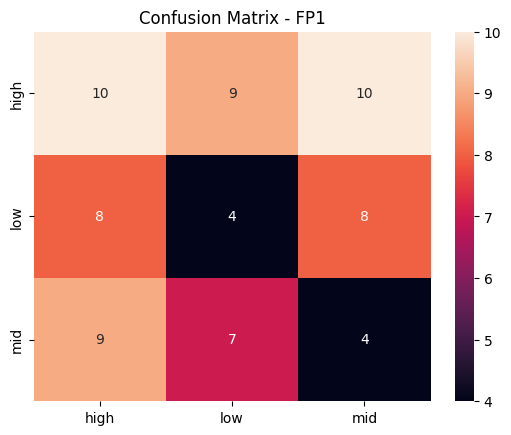

In [21]:
# --------------------------------------------------
# Cell 11: Final classification with selected features (SAFE VERSION)
# --------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

channel_example = "FP1"   # <-- FP1 only
channel_dir = OUT_FEATURE_DIR / channel_example
files = sorted(channel_dir.glob("ID*_feature.csv"))

print(f"\n=== Running Final Classification for Channel: {channel_example} ===")

# Load selected indices
sel_idx_path = OUT_FEATURE_DIR / f"{channel_example}_inca_selected_idx.npy"
if not sel_idx_path.exists():
    print("❌ No INCA-selected indices found.")
    raise SystemExit()

sel_idx = np.load(sel_idx_path)

# --------------------------
# 1. Build X, y with subject IDs
# --------------------------
rows = []
labels = []
subj_rowids = []

def map_label(score):
    if score in (1,2,3,4): return "low"
    if score in (5,6): return "mid"
    if score in (7,8,9): return "high"
    return None


for f in files:
    sid = int("".join([c for c in f.stem if c.isdigit()]))
    df = pd.read_csv(f)

    score = sid_to_score.get(sid, None)
    lab = map_label(score)

    if lab is None:
        continue

    feats = df.drop(columns=["subj_id", "window_idx", "pain_score", "label"], errors="ignore").values

    rows.append(feats)
    labels.extend([lab] * len(feats))
    subj_rowids.extend([sid] * len(feats))

X = np.vstack(rows)
y = np.array(labels)
subj_rowids = np.array(subj_rowids)

print("X:", X.shape, "  y:", y.shape, " subjects:", len(np.unique(subj_rowids)))

# --------------------------
# 2. Prepare subjects for SAFE stratified split
# --------------------------
valid_subjs = []
valid_labels = []

for s in np.unique(subj_rowids):
    score = sid_to_score.get(s, None)
    lab = map_label(score)
    if lab is not None:
        valid_subjs.append(s)
        valid_labels.append(lab)

valid_subjs = np.array(valid_subjs)
valid_labels = np.array(valid_labels)

print("\nValid subjects:", valid_subjs)
print("Labels:", valid_labels)

# --------------------------
# 3. Split subjects (SAFE STRATIFY)
# --------------------------
train_subj, test_subj = train_test_split(
    valid_subjs,
    test_size=0.2,
    random_state=0,
    stratify=valid_labels
)

train_idx = np.isin(subj_rowids, train_subj)
test_idx = np.isin(subj_rowids, test_subj)

X_train = X[train_idx][:, sel_idx]
X_test  = X[test_idx][:, sel_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print("\nTrain subjects:", train_subj)
print("Test subjects:", test_subj)

# --------------------------
# 4. Train classifier
# --------------------------
clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {channel_example}')
plt.show()


In [22]:
# --------------------------------------------------
# FINAL MULTI-CHANNEL CLASSIFICATION (ALL 24 CHANNELS)
# --------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

print("\n=========== FINAL CLASSIFICATION FOR ALL CHANNELS ===========\n")

results = []

for ch in CHANNELS:
    print(f"\n==================== CHANNEL: {ch} ====================")

    channel_dir = OUT_FEATURE_DIR / ch
    files = sorted(channel_dir.glob("ID*_feature.csv"))

    inca_path = OUT_FEATURE_DIR / f"{ch}_inca_selected_idx.npy"
    if not inca_path.exists():
        print(f"⚠️ No INCA indices found for {ch} — skipping")
        continue

    sel_idx = np.load(inca_path)

    rows = []
    labels = []
    subj_rowids = []

    for f in files:
        sid = int("".join([c for c in f.stem if c.isdigit()]))
        df = pd.read_csv(f)

        score = sid_to_score.get(sid, None)
        lab = map_label(score)

        if lab is None:
            continue

        feats = df.drop(columns=["subj_id", "window_idx", "pain_score", "label"], errors="ignore").values

        rows.append(feats)
        labels.extend([lab] * len(feats))
        subj_rowids.extend([sid] * len(feats))

    if len(rows) == 0:
        print(f"⚠️ No valid labeled files for channel {ch}")
        continue

    X = np.vstack(rows)
    y = np.array(labels)
    subj_rowids = np.array(subj_rowids)

    # -------- FILTER VALID SUBJECTS --------
    valid_subjs = []
    valid_labels = []
    for s in np.unique(subj_rowids):
        score = sid_to_score.get(s, None)
        lab = map_label(score)
        if lab is not None:
            valid_subjs.append(s)
            valid_labels.append(lab)

    valid_subjs = np.array(valid_subjs)
    valid_labels = np.array(valid_labels)

    # -------- STRATIFIED SUBJECT SPLIT --------
    train_subj, test_subj = train_test_split(
        valid_subjs,
        test_size=0.2,
        random_state=0,
        stratify=valid_labels
    )

    train_idx = np.isin(subj_rowids, train_subj)
    test_idx  = np.isin(subj_rowids, test_subj)

    X_train = X[train_idx][:, sel_idx]
    X_test  = X[test_idx][:, sel_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({ch}):", acc)

    results.append((ch, acc))

print("\n=============== SUMMARY ===============")
for ch, acc in results:
    print(f"{ch:5s} → {acc:.4f}")



=========== FINAL CLASSIFICATION FOR ALL CHANNELS ===========


==================== CHANNEL: FP1 ====================
Accuracy (FP1): 0.2608695652173913

==================== CHANNEL: FP2 ====================
Accuracy (FP2): 0.34782608695652173

==================== CHANNEL: F3 ====================
Accuracy (F3): 0.2463768115942029

==================== CHANNEL: F4 ====================
Accuracy (F4): 0.391304347826087

==================== CHANNEL: C3 ====================
Accuracy (C3): 0.2898550724637681

==================== CHANNEL: C4 ====================
Accuracy (C4): 0.2318840579710145

==================== CHANNEL: P3 ====================
Accuracy (P3): 0.2898550724637681

==================== CHANNEL: P4 ====================
Accuracy (P4): 0.37681159420289856

==================== CHANNEL: O1 ====================
Accuracy (O1): 0.463768115942029

==================== CHANNEL: O2 ====================
Accuracy (O2): 0.30434782608695654

==================== CHANNEL: F7 =======


=== Running Final Classification for Channel: POz ===
X: (339, 2970)   y: (339,)  subjects: 34

Valid subjects: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 18 19 20 21 22 23 24 25
 27 30 31 33 35 38 39 40 41 43]
Labels: ['high' 'low' 'low' 'high' 'mid' 'low' 'high' 'low' 'low' 'high' 'low'
 'mid' 'low' 'low' 'high' 'mid' 'mid' 'high' 'high' 'mid' 'high' 'mid'
 'high' 'high' 'low' 'low' 'high' 'mid' 'low' 'high' 'high' 'low' 'high'
 'mid']

Train subjects: [18  7  5 41 10 15 22 25 23 16  6  9  1 33 31 20 43  3  8  2 13 40 38 14
 24 21 30]
Test subjects: [35 39 19  4  0 11 27]

Final Test Accuracy: 0.4782608695652174

Classification Report:
              precision    recall  f1-score   support

        high       0.56      0.52      0.54        29
         low       0.37      0.50      0.43        20
         mid       0.53      0.40      0.46        20

    accuracy                           0.48        69
   macro avg       0.49      0.47      0.47        69
weighted avg       0.

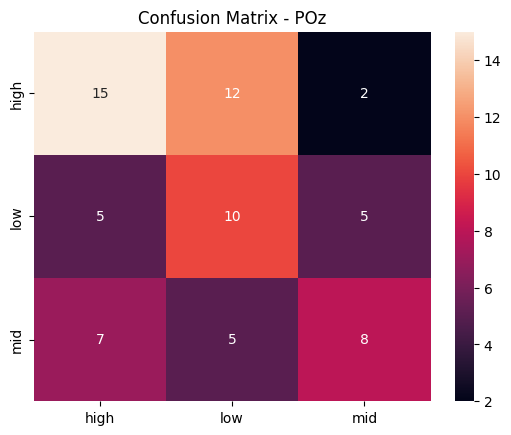

In [23]:
# Highest accuracy channel is POz with accuracy 0.47 so run for that channel only:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

channel_example = "POz"   # <-- FP1 only
channel_dir = OUT_FEATURE_DIR / channel_example
files = sorted(channel_dir.glob("ID*_feature.csv"))

print(f"\n=== Running Final Classification for Channel: {channel_example} ===")

# Load selected indices
sel_idx_path = OUT_FEATURE_DIR / f"{channel_example}_inca_selected_idx.npy"
if not sel_idx_path.exists():
    print("❌ No INCA-selected indices found.")
    raise SystemExit()

sel_idx = np.load(sel_idx_path)

# --------------------------
# 1. Build X, y with subject IDs
# --------------------------
rows = []
labels = []
subj_rowids = []

def map_label(score):
    if score in (1,2,3,4): return "low"
    if score in (5,6): return "mid"
    if score in (7,8,9): return "high"
    return None


for f in files:
    sid = int("".join([c for c in f.stem if c.isdigit()]))
    df = pd.read_csv(f)

    score = sid_to_score.get(sid, None)
    lab = map_label(score)

    if lab is None:
        continue

    feats = df.drop(columns=["subj_id", "window_idx", "pain_score", "label"], errors="ignore").values

    rows.append(feats)
    labels.extend([lab] * len(feats))
    subj_rowids.extend([sid] * len(feats))

X = np.vstack(rows)
y = np.array(labels)
subj_rowids = np.array(subj_rowids)

print("X:", X.shape, "  y:", y.shape, " subjects:", len(np.unique(subj_rowids)))

# --------------------------
# 2. Prepare subjects for SAFE stratified split
# --------------------------
valid_subjs = []
valid_labels = []

for s in np.unique(subj_rowids):
    score = sid_to_score.get(s, None)
    lab = map_label(score)
    if lab is not None:
        valid_subjs.append(s)
        valid_labels.append(lab)

valid_subjs = np.array(valid_subjs)
valid_labels = np.array(valid_labels)

print("\nValid subjects:", valid_subjs)
print("Labels:", valid_labels)

# --------------------------
# 3. Split subjects (SAFE STRATIFY)
# --------------------------
train_subj, test_subj = train_test_split(
    valid_subjs,
    test_size=0.2,
    random_state=0,
    stratify=valid_labels
)

train_idx = np.isin(subj_rowids, train_subj)
test_idx = np.isin(subj_rowids, test_subj)

X_train = X[train_idx][:, sel_idx]
X_test  = X[test_idx][:, sel_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print("\nTrain subjects:", train_subj)
print("Test subjects:", test_subj)

# --------------------------
# 4. Train classifier
# --------------------------
clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {channel_example}')
plt.show()


🔁 Building fused feature matrix from per-channel CSVs ...


Subjects:   0%|          | 0/37 [00:00<?, ?it/s]

Subjects: 100%|██████████| 37/37 [00:37<00:00,  1.00s/it]


Fused X shape: (339, 71280)  (samples x features)
Total labeled subjects used: 34
Skipped subjects (no/invalid label): [26, 37, 151]
🧹 Cleaning NaN/Inf ...
Done cleaning: NaN= 0 Inf= 0
Label classes: ['high' 'low' 'mid']
📉 Running PCA: components=200 (n_samples=339) ...
After PCA shape: (339, 200)
🔎 Running INCA-like selection on PCA-reduced data ...
Selected PCA-components (k=40), CV acc=0.6637
Saved selected PCA indices → FUSED_pca_selected_idx.npy
Train subjects: 27 Test subjects: 7
Final shapes -> X_train: (270, 40) X_test: (69, 40) y_train: (270,) y_test: (69,)

✅ FINAL TEST ACCURACY = 0.2609

Classification report:

              precision    recall  f1-score   support

        high       0.32      0.21      0.25        29
         low       0.29      0.40      0.33        20
         mid       0.18      0.20      0.19        20

    accuracy                           0.26        69
   macro avg       0.26      0.27      0.26        69
weighted avg       0.27      0.26      0.26 

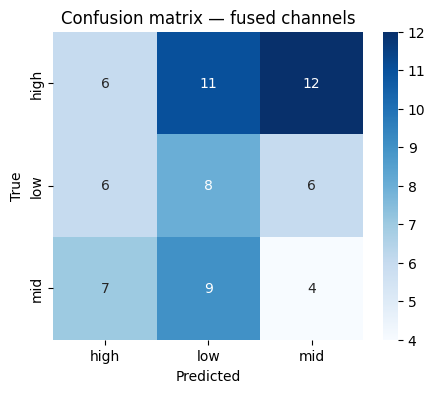

Saved artifacts: FUSED_pca_X.npy, FUSED_sel_pca_idx.npy, FUSED_subject_info.csv


In [25]:
# =========================
# FUSED-CHANNELS PIPELINE
# PCA -> NCA (INCA-like) -> Subject-level classification
# Single runnable block
# =========================

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis, KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG - change only if needed
# -----------------------------
FEATURE_OUT = Path("Paper_Repro_Features")   # top-level folder with channel subfolders
CHANNELS = [
    'FP1','FP2','F3','F4','C3','C4','P3','P4','O1','O2',
    'F7','F8','T7','T8','P7','P8','Fz','Cz','Pz',
    'M1','M2','AFz','CPz','POz'
]
LABEL_PATH_XLSX = Path("labels.xlsx")
LABEL_PATH_CSV  = Path("labels.csv")

# PCA / INCA settings (safe defaults)
MAX_PCA_COMPONENTS = 200        # upper limit for PCA components (will be clamped by n_samples-1)
INCA_START = 10
INCA_END = 150
INCA_STEP = 10
NCA_N_SPLITS = 5  # CV folds used inside INCA-like selection

# Final classifier
FINAL_K = 1
FINAL_METRIC = "manhattan"

# -----------------------------
# Load labels
# -----------------------------
if LABEL_PATH_XLSX.exists():
    labels_df = pd.read_excel(LABEL_PATH_XLSX)
elif LABEL_PATH_CSV.exists():
    labels_df = pd.read_csv(LABEL_PATH_CSV)
else:
    raise SystemExit("No labels.xlsx or labels.csv found. Add file with columns: ID, PainScore")

# build mapping ID -> pain score
sid_to_score = dict(zip(labels_df["ID"].astype(int), labels_df["PainScore"]))

def map_label(score):
    if score in (1,2,3,4): return "low"
    if score in (5,6): return "mid"
    if score in (7,8,9): return "high"
    return None

# -----------------------------
# Build fused matrix X, y, subj_ids
# -----------------------------
print("🔁 Building fused feature matrix from per-channel CSVs ...")
base_channel = CHANNELS[0]
base_dir = FEATURE_OUT / base_channel
base_files = sorted(base_dir.glob("ID*_feature.csv"))

fused_rows = []
fused_labels = []
fused_subj_ids = []

skipped_subjects = []

for base_file in tqdm(base_files, desc="Subjects"):
    sid = int("".join([c for c in base_file.stem if c.isdigit()]))
    score = sid_to_score.get(sid, None)
    lbl = map_label(score)
    if lbl is None:
        skipped_subjects.append(sid)
        continue

    # load base channel
    df_base = pd.read_csv(base_file)
    # assume each channel csv has subj_id, window_idx, pain_score, label plus features
    n_windows = len(df_base)
    feats = df_base.drop(columns=["subj_id","window_idx","pain_score","label"], errors="ignore").values

    # append features from other channels (must match window count)
    for ch in CHANNELS[1:]:
        ch_file = FEATURE_OUT / ch / f"ID{sid}_feature.csv"
        if not ch_file.exists():
            raise FileNotFoundError(f"Missing feature file for ID{sid}, channel {ch}: {ch_file}")
        df_ch = pd.read_csv(ch_file)
        if len(df_ch) != n_windows:
            raise ValueError(f"Window count mismatch for ID{sid} channel {ch}: base {n_windows} vs {len(df_ch)}")
        ch_feats = df_ch.drop(columns=["subj_id","window_idx","pain_score","label"], errors="ignore").values
        feats = np.hstack([feats, ch_feats])

    fused_rows.append(feats)
    fused_labels.extend([lbl] * n_windows)
    fused_subj_ids.extend([sid] * n_windows)

if len(fused_rows) == 0:
    raise SystemExit("No labeled subjects found. Check labels file and feature CSVs.")

X = np.vstack(fused_rows)        # shape: (total_windows, total_features)
y = np.array(fused_labels)
subj_ids = np.array(fused_subj_ids)

print(f"Fused X shape: {X.shape}  (samples x features)")
print(f"Total labeled subjects used: {len(np.unique(subj_ids))}")
print(f"Skipped subjects (no/invalid label): {sorted(set(skipped_subjects))}")

# -----------------------------
# Clean NaN / Inf
# -----------------------------
print("🧹 Cleaning NaN/Inf ...")
col_means = np.nanmean(X, axis=0)
col_means = np.where(np.isnan(col_means), 0.0, col_means)
inds = np.where(np.isnan(X))
if inds[0].size:
    X[inds] = np.take(col_means, inds[1])
X = np.nan_to_num(X, posinf=0.0, neginf=0.0)
print("Done cleaning:", "NaN=", np.isnan(X).sum(), "Inf=", np.isinf(X).sum())

# -----------------------------
# Encode labels
# -----------------------------
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label classes:", le.classes_)

# -----------------------------
# PCA reduction (safe)
# -----------------------------
n_samples = X.shape[0]
max_possible = max(1, n_samples - 1)
pca_components = min(MAX_PCA_COMPONENTS, max_possible, X.shape[1])
print(f"📉 Running PCA: components={pca_components} (n_samples={n_samples}) ...")
pca = PCA(n_components=pca_components, svd_solver='randomized', random_state=0)
X_pca = pca.fit_transform(X)
print("After PCA shape:", X_pca.shape)

# -----------------------------
# INCA-like selection (NCA ranking + small sweep)
# -----------------------------
def nca_feature_ranking(X_small, y_small):
    # Fit NCA on reduced data to get per-dimension importance
    nca = NeighborhoodComponentsAnalysis(random_state=0)
    nca.fit(X_small, y_small)
    comps = nca.components_            # shape (n_components, n_features_reduced)
    # feature importance = L2 norm across components
    scores = np.linalg.norm(comps, axis=0)
    return scores

def inca_like_selection(X_small, y_small, start=INCA_START, end=INCA_END, step=INCA_STEP):
    scores = nca_feature_ranking(X_small, y_small)
    ranked_idx = np.argsort(-scores)
    best_k = None
    best_acc = -np.inf
    all_res = []
    end = min(end, X_small.shape[1])
    for k in range(start, end+1, step):
        idx_k = ranked_idx[:k]
        skf = StratifiedKFold(n_splits=min(NCA_N_SPLITS, len(np.unique(y_small))), shuffle=True, random_state=0)
        accs = []
        for tr, te in skf.split(X_small, y_small):
            clf = KNeighborsClassifier(n_neighbors=FINAL_K, metric=FINAL_METRIC)
            clf.fit(X_small[tr][:, idx_k], y_small[tr])
            pred = clf.predict(X_small[te][:, idx_k])
            accs.append(accuracy_score(y_small[te], pred))
        mean_acc = float(np.mean(accs))
        all_res.append((k, mean_acc))
        if mean_acc > best_acc:
            best_acc = mean_acc
            best_k = k
    # return selected indices in PCA-space, k, score, and all results
    return ranked_idx[:best_k], best_k, best_acc, all_res

print("🔎 Running INCA-like selection on PCA-reduced data ...")
sel_pca_idx, sel_k, sel_score, all_res = inca_like_selection(
    X_pca, y_enc,
    start=max(1, INCA_START), end=max(1, min(INCA_END, X_pca.shape[1])), step=max(1, INCA_STEP)
)

print(f"Selected PCA-components (k={sel_k}), CV acc={sel_score:.4f}")
np.save("FUSED_pca_selected_idx.npy", sel_pca_idx)
print("Saved selected PCA indices → FUSED_pca_selected_idx.npy")

# -----------------------------
# Subject-level train/test split (stratified if possible)
# -----------------------------
unique_subjs = np.unique(subj_ids)
strat_vec = []
for s in unique_subjs:
    sc = sid_to_score.get(int(s), None)
    if sc is None:
        strat_vec.append(None)
    else:
        strat_vec.append(map_label(sc))

# try stratified split by subject labels; if fails, fall back to non-stratified
try:
    train_subj, test_subj = train_test_split(unique_subjs, test_size=0.2, random_state=0, stratify=strat_vec)
except Exception as e:
    print("⚠️ Stratified subject split failed:", e)
    print("→ Falling back to random subject-level split (non-stratified).")
    train_subj, test_subj = train_test_split(unique_subjs, test_size=0.2, random_state=0, stratify=None)

print("Train subjects:", len(train_subj), "Test subjects:", len(test_subj))
train_mask = np.isin(subj_ids, train_subj)
test_mask  = np.isin(subj_ids, test_subj)

# apply selected PCA indices for classification
X_train = X_pca[train_mask][:, sel_pca_idx]
X_test  = X_pca[test_mask][:, sel_pca_idx]
y_train = y_enc[train_mask]
y_test  = y_enc[test_mask]

print("Final shapes -> X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)

# -----------------------------
# Train & Evaluate final classifier
# -----------------------------
clf = KNeighborsClassifier(n_neighbors=FINAL_K, metric=FINAL_METRIC)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n✅ FINAL TEST ACCURACY = {acc:.4f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion matrix — fused channels")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# -----------------------------
# Save results
# -----------------------------
np.save("FUSED_pca_X.npy", X_pca)                # optional: PCA-projected full matrix
np.save("FUSED_sel_pca_idx.npy", sel_pca_idx)
pd.DataFrame({"subject_ids": subj_ids, "label": y, "label_enc": y_enc}).to_csv("FUSED_subject_info.csv", index=False)
print("Saved artifacts: FUSED_pca_X.npy, FUSED_sel_pca_idx.npy, FUSED_subject_info.csv")


In [ ]:

# --------------------------------------------------
# Cell 12: Cortex map visualization (per-channel accuracies)
# --------------------------------------------------
# After running per-channel classification for all channels you can assemble channel accuracies
# into a DataFrame channels x accuracy and compute median and intersection as in paper.

print('Notebook end.\n\nNotes:')
print('- This notebook attempts to follow the paper exactly but uses pragmatic approximations where needed (TQWT fallback, INCA approx).')
print('- You will need to provide a labels.csv file mapping subject ID to PainScore to run supervised steps.')
print('- Running full pipeline is computationally heavy — test on 1-2 channels first.')

